In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import re
import requests
import json

def get_entry_from_api(pdb_id, apiurl):
    """
    This function will make a call to the PDBe API using
    the PDB id and API url provided as arguments

    :param pdb_id: String,
    :param api_url: String
    :return: Dict or None
    """
    if not re.match("[0-9][A-Za-z][A-Za-z0-9]{2}", pdb_id):
        print("Invalid PDB id")
        return None

    # Make a GET call to the API URL
    get_request = requests.get(url=apiurl+pdb_id)

    if get_request.status_code == 200:
        # If there is data returned (with HTML status code 200)
        # then return the data in JSON format
        return get_request.json()
    else:
        # If there is no data, print status code and response
        print(get_request.status_code, get_request.text)
        return None


In [2]:
file_path = '/content/drive/MyDrive/dati/swpdb.tsv'
try:
    uniprot = pd.read_csv(file_path, delimiter="\t")
except Exception as e:
    print(f"An error occurred while loading the file: {e}")

In [3]:
uniprot.shape

(658, 4)

In [4]:
summary = "https://www.ebi.ac.uk/pdbe/api/pdb/entry/summary/"
experiment = "https://www.ebi.ac.uk/pdbe/api/pdb/entry/experiment/"
uniprot_mapping = "https://www.ebi.ac.uk/pdbe/api/mappings/uniprot/"

In [5]:
pdbs = list(uniprot['From'].value_counts().to_dict().keys())

In [6]:
len(pdbs)

311

In [7]:
experimental_method = []
resolution = []
for el in pdbs:
  protein = get_entry_from_api(el, experiment)
  experimental_method.append(protein[el.lower()][0]['experimental_method'])
  resolution.append(protein[el.lower()][0].get("resolution"))

In [8]:
unis = list(uniprot.groupby('From')['Entry'].apply(list).to_dict().values())
len(unis)


311

In [9]:
metadata = pd.DataFrame({"PDB":pdbs, "Uniprot(s)": unis, "Method":experimental_method, "Resolution": resolution})
metadata.shape

(311, 4)

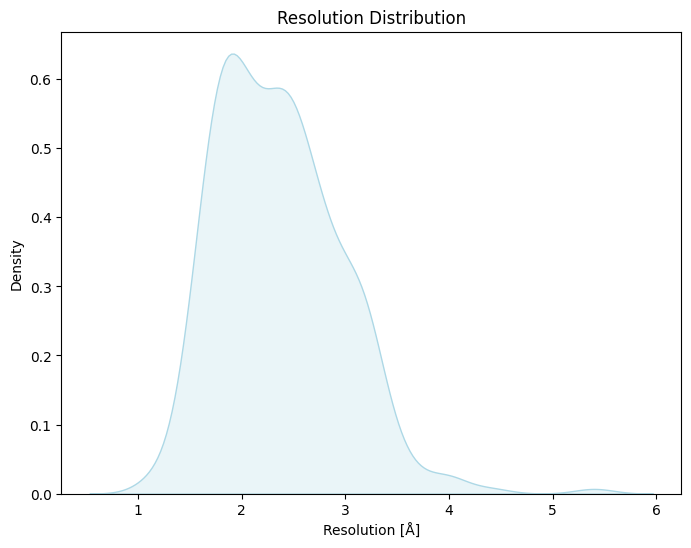

In [10]:
plt.figure(figsize=(8, 6))
sns.kdeplot(data=metadata, x='Resolution', fill=True, color = 'lightblue')
plt.title('Resolution Distribution')
plt.xlabel('Resolution [Å]')
plt.show()

In [11]:
method_dist = metadata[['Method']].value_counts().to_dict()
for key in method_dist:
  print(str(key)[2:-3], method_dist[key])

X-ray diffraction 309
Solution NMR 2


In [12]:
print(min(metadata['Resolution']))

1.1


In [13]:
print(max(metadata['Resolution']))

5.4


In [14]:
resolution_dist = metadata[['Resolution']].value_counts().to_dict()


In [15]:
coverage = {}
for el in pdbs:
  data = get_entry_from_api(el, uniprot_mapping)
  coverage[el]={}
  for uniprot_id, details in data[el.lower()]["UniProt"].items():
      coverage[el][uniprot_id]=-1
      for m in details["mappings"]:
        start = m["start"]["residue_number"]
        end = m["end"]["residue_number"]
        covered_residues = end - start + 1
        if coverage[el][uniprot_id]<covered_residues:
          coverage[el][uniprot_id]=covered_residues
len(coverage)

311

In [16]:
coverage

{'1BD2': {'P04439': 275,
  'P61769': 99,
  'P0C213': 9,
  'P04437': 91,
  'P01848': 93,
  'A0A0K0K1A5': 95,
  'A0A5B9': 129},
 '1AO7': {'P04439': 275,
  'P61769': 99,
  'P14079': 9,
  'A0A075B6T6': 90,
  'P01848': 93,
  'P01850': 129},
 '2BNQ': {'P04439': 275,
  'P61769': 99,
  'P78358': 8,
  'A0A0B4J279': 92,
  'P01848': 89,
  'A0A0K0K1A5': 93,
  'P01850': 129},
 '2VLR': {'P04439': 275,
  'P61769': 99,
  'P03485': 9,
  'P01848': 89,
  'P01850': 129},
 '2BNR': {'P04439': 275,
  'P61769': 99,
  'P78358': 9,
  'A0A0B4J279': 92,
  'P01848': 89,
  'A0A0K0K1A5': 93,
  'P01850': 129},
 '1OGA': {'P04439': 275, 'P61769': 99, 'P01848': 92, 'P01850': 129},
 '2AK4': {'P01889': 276,
  'P61769': 99,
  'P03206': 13,
  'P01848': 93,
  'P01850': 129},
 '2P5E': {'P04439': 275, 'P61769': 99, 'P78358': 9, 'P01848': 79},
 '1LP9': {'P04439': 275,
  'P61769': 99,
  'Q9NPA0': 9,
  'P01849': 79,
  'P04213': 113},
 '4JFF': {'P04439': 275,
  'P61769': 99,
  'Q16655': 10,
  'P01848': 87,
  'P01850': 129},
 '2J8U

In [17]:
pdbs = []
uniprots = []
coverages = []
expmet = []
res = []
i = 0
for key in coverage:
  for k in coverage[key]:
    pdbs.append(key)
    uniprots.append(k)
    coverages.append(coverage[key][k])
    expmet.append(experimental_method[i])
    res.append(resolution[i])
  i+=1
coverage_df = pd.DataFrame({'PDB':pdbs, 'Experimental Method':expmet, 'Resolution':res, 'Uniprot':uniprots, 'Coverage': coverages})


In [18]:
coverage_df.shape

(682, 5)

In [19]:
coverage_df

,PDB,Experimental Method,Resolution,Uniprot,Coverage
0,1BD2,X-ray diffraction,2.5,P04439,275
1,1BD2,X-ray diffraction,2.5,P61769,99
2,1BD2,X-ray diffraction,2.5,P0C213,9
3,1BD2,X-ray diffraction,2.5,P04437,91
4,1BD2,X-ray diffraction,2.5,P01848,93
...,...,...,...,...,...
677,2I26,X-ray diffraction,2.5,Q8JGG7,84
678,5C6T,X-ray diffraction,3.6,P13201,612
679,1YQV,X-ray diffraction,1.7,P00698,129
680,1TM1,X-ray diffraction,1.7,P00782,275


In [25]:
up = uniprot['Entry'].to_list()
lengths = uniprot['Length'].to_list()

In [26]:
leng={}
for i in range(len(up)):
  leng[up[i]]=lengths[i]

In [28]:
coverage_df['Length'] = coverage_df['Uniprot'].map(leng)
display(coverage_df.head())

,PDB,Experimental Method,Resolution,Uniprot,Coverage,Uniprot Length,Length
0,1BD2,X-ray diffraction,2.5,P04439,275,365.0,365.0
1,1BD2,X-ray diffraction,2.5,P61769,99,119.0,119.0
2,1BD2,X-ray diffraction,2.5,P0C213,9,353.0,353.0
3,1BD2,X-ray diffraction,2.5,P04437,91,119.0,119.0
4,1BD2,X-ray diffraction,2.5,P01848,93,140.0,140.0


In [29]:
coverage_df = coverage_df.drop(columns=coverage_df.columns[-1])
display(coverage_df.head())

,PDB,Experimental Method,Resolution,Uniprot,Coverage,Uniprot Length
0,1BD2,X-ray diffraction,2.5,P04439,275,365.0
1,1BD2,X-ray diffraction,2.5,P61769,99,119.0
2,1BD2,X-ray diffraction,2.5,P0C213,9,353.0
3,1BD2,X-ray diffraction,2.5,P04437,91,119.0
4,1BD2,X-ray diffraction,2.5,P01848,93,140.0


In [31]:
length = coverage_df['Uniprot Length'].to_numpy()
coverage = coverage_df['Coverage'].to_numpy()
covperc = coverage/length*100
coverage_df['Coverage (%)']=pd.Series(covperc)
coverage_df.head()

,PDB,Experimental Method,Resolution,Uniprot,Coverage,Uniprot Length,Coverage (%)
0,1BD2,X-ray diffraction,2.5,P04439,275,365.0,75.342466
1,1BD2,X-ray diffraction,2.5,P61769,99,119.0,83.193277
2,1BD2,X-ray diffraction,2.5,P0C213,9,353.0,2.549575
3,1BD2,X-ray diffraction,2.5,P04437,91,119.0,76.470588
4,1BD2,X-ray diffraction,2.5,P01848,93,140.0,66.428571


In [32]:
coverage_df = coverage_df.rename(columns={'Uniprot Length': 'Length'})
display(coverage_df.head())

,PDB,Experimental Method,Resolution,Uniprot,Coverage,Length,Coverage (%)
0,1BD2,X-ray diffraction,2.5,P04439,275,365.0,75.342466
1,1BD2,X-ray diffraction,2.5,P61769,99,119.0,83.193277
2,1BD2,X-ray diffraction,2.5,P0C213,9,353.0,2.549575
3,1BD2,X-ray diffraction,2.5,P04437,91,119.0,76.470588
4,1BD2,X-ray diffraction,2.5,P01848,93,140.0,66.428571


In [55]:
file_path = '/content/drive/MyDrive/dati/unr.tsv'
try:
    unrev = pd.read_csv(file_path, delimiter="\t")
except Exception as e:
    print(f"An error occurred while loading the file: {e}")

In [56]:
pdbs = list(unrev['From'].value_counts().to_dict().keys())

In [57]:
len(pdbs)

8

In [58]:
experimental_method = []
resolution = []
for el in pdbs:
  protein = get_entry_from_api(el, experiment)
  experimental_method.append(protein[el.lower()][0]['experimental_method'])
  resolution.append(protein[el.lower()][0].get("resolution"))

In [59]:
unis = list(unrev.groupby('From')['Entry'].apply(list).to_dict().values())
len(unis)


8

In [60]:
metadata = pd.DataFrame({"PDB":pdbs, "Uniprot(s)": unis, "Method":experimental_method, "Resolution": resolution})
metadata.shape

(8, 4)

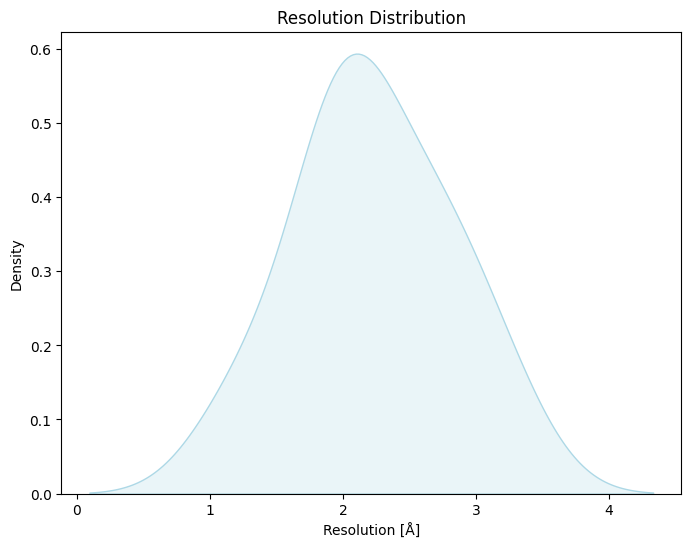

In [61]:
plt.figure(figsize=(8, 6))
sns.kdeplot(data=metadata, x='Resolution', fill=True, color = 'lightblue')
plt.title('Resolution Distribution')
plt.xlabel('Resolution [Å]')
plt.show()

In [62]:
method_dist = metadata[['Method']].value_counts().to_dict()
for key in method_dist:
  print(str(key)[2:-3], method_dist[key])

X-ray diffraction 8


In [63]:
print(min(metadata['Resolution']))

1.26


In [64]:
print(max(metadata['Resolution']))

3.166


In [65]:
resolution_dist = metadata[['Resolution']].value_counts().to_dict()


In [66]:
coverage = {}
for el in pdbs:
  data = get_entry_from_api(el, uniprot_mapping)
  coverage[el]={}
  for uniprot_id, details in data[el.lower()]["UniProt"].items():
      coverage[el][uniprot_id]=-1
      for m in details["mappings"]:
        start = m["start"]["residue_number"]
        end = m["end"]["residue_number"]
        covered_residues = end - start + 1
        if coverage[el][uniprot_id]<covered_residues:
          coverage[el][uniprot_id]=covered_residues
len(coverage)

8

In [67]:
coverage

{'4CVW': {'O48541': 482, 'Q2V8X0': 114},
 '4HFK': {'A0A0H3CIJ2': 163, 'A0A0H3CIX8': 99},
 '3QHY': {'Q93T42': 271, 'O87916': 271},
 '3NGB': {'Q0ED31': 162},
 '3SE9': {'Q0ED31': 353},
 '4ZS6': {'W6A0A7': 223},
 '3SE8': {'Q0ED31': 353},
 '5M2O': {'A0AEF4': 146}}

In [68]:
pdbs = []
uniprots = []
coverages = []
expmet = []
res = []
i = 0
for key in coverage:
  for k in coverage[key]:
    pdbs.append(key)
    uniprots.append(k)
    coverages.append(coverage[key][k])
    expmet.append(experimental_method[i])
    res.append(resolution[i])
  i+=1
df = pd.DataFrame({'PDB':pdbs, 'Experimental Method':expmet, 'Resolution':res, 'Uniprot':uniprots, 'Coverage': coverages})


In [69]:
df.shape

(11, 5)

In [70]:
df

,PDB,Experimental Method,Resolution,Uniprot,Coverage
0,4CVW,X-ray diffraction,2.670,O48541,482
1,4CVW,X-ray diffraction,2.670,Q2V8X0,114
2,4HFK,X-ray diffraction,2.100,A0A0H3CIJ2,163
3,4HFK,X-ray diffraction,2.100,A0A0H3CIX8,99
4,3QHY,X-ray diffraction,2.060,Q93T42,271
5,3QHY,X-ray diffraction,2.060,O87916,271
6,3NGB,X-ray diffraction,2.680,Q0ED31,162
7,3SE9,X-ray diffraction,2.000,Q0ED31,353
8,4ZS6,X-ray diffraction,3.166,W6A0A7,223
9,3SE8,X-ray diffraction,1.895,Q0ED31,353


In [71]:
up = unrev['Entry'].to_list()
lengths = unrev['Length'].to_list()

In [72]:
leng={}
for i in range(len(up)):
  leng[up[i]]=lengths[i]

In [73]:
df['Length'] = df['Uniprot'].map(leng)
display(df.head())

,PDB,Experimental Method,Resolution,Uniprot,Coverage,Length
0,4CVW,X-ray diffraction,2.67,O48541,482,904
1,4CVW,X-ray diffraction,2.67,Q2V8X0,114,147
2,4HFK,X-ray diffraction,2.10,A0A0H3CIJ2,163,163
3,4HFK,X-ray diffraction,2.10,A0A0H3CIX8,99,117
4,3QHY,X-ray diffraction,2.06,Q93T42,271,309


In [74]:
length = df['Length'].to_numpy()
coverage = df['Coverage'].to_numpy()
covperc = coverage/length*100
df['Coverage (%)']=pd.Series(covperc)
df.head()

,PDB,Experimental Method,Resolution,Uniprot,Coverage,Length,Coverage (%)
0,4CVW,X-ray diffraction,2.67,O48541,482,904,53.318584
1,4CVW,X-ray diffraction,2.67,Q2V8X0,114,147,77.551020
2,4HFK,X-ray diffraction,2.10,A0A0H3CIJ2,163,163,100.000000
3,4HFK,X-ray diffraction,2.10,A0A0H3CIX8,99,117,84.615385
4,3QHY,X-ray diffraction,2.06,Q93T42,271,309,87.702265


In [75]:
metadata = pd.concat([coverage_df, df], ignore_index=True)
display(metadata.head())

,PDB,Experimental Method,Resolution,Uniprot,Coverage,Length,Coverage (%)
0,1BD2,X-ray diffraction,2.5,P04439,275,365.0,75.342466
1,1BD2,X-ray diffraction,2.5,P61769,99,119.0,83.193277
2,1BD2,X-ray diffraction,2.5,P0C213,9,353.0,2.549575
3,1BD2,X-ray diffraction,2.5,P04437,91,119.0,76.470588
4,1BD2,X-ray diffraction,2.5,P01848,93,140.0,66.428571


In [76]:
metadata.shape

(693, 7)

In [77]:
metadata.to_csv('metadata.tsv', sep='\t', index=False)

In [92]:
display(metadata['Resolution'].describe())

,Resolution
count,689.000000
mean,2.369190
std,0.589604
min,1.100000
25%,1.900000
50%,2.350000
75%,2.700000
max,5.400000


In [83]:
pdbs = list(metadata['PDB'].value_counts().to_dict().keys())

In [84]:
len(pdbs)

319

In [88]:
resolution = list(metadata.groupby('PDB')['Resolution'].apply(list).to_dict().values())
len(resolution)

319

In [89]:
metadat = pd.DataFrame({"PDB":pdbs, "Resolution": resolution})
metadat.shape

(319, 2)

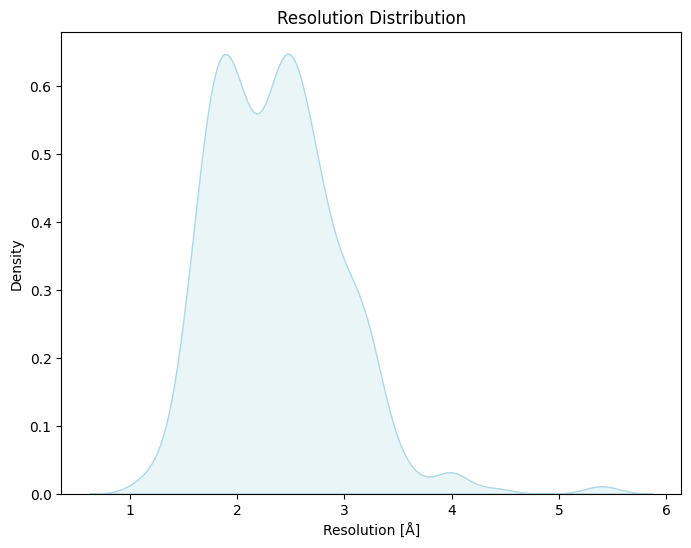

In [94]:
plt.figure(figsize=(8, 6))
exploded_metadat = metadat.explode('Resolution').reset_index(drop=True)
sns.kdeplot(data=exploded_metadat, x='Resolution', fill=True, color='lightblue')
plt.title('Resolution Distribution')
plt.xlabel('Resolution [Å]')
plt.show()

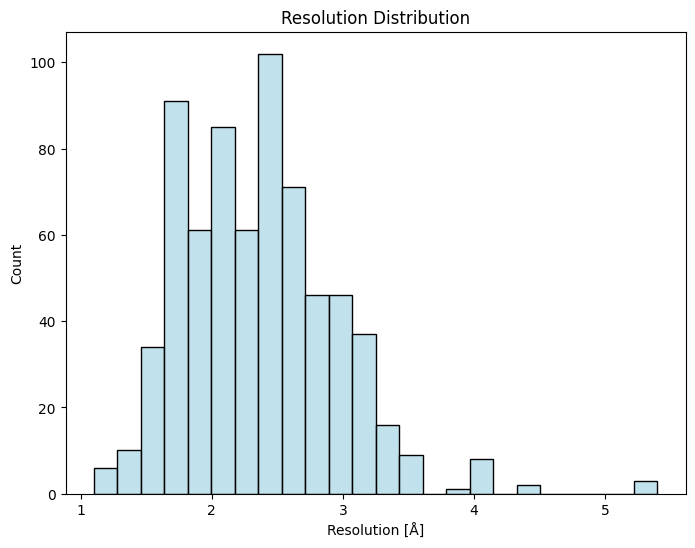

In [95]:
plt.figure(figsize=(8, 6))
exploded_metadat = metadat.explode('Resolution').reset_index(drop=True)
sns.histplot(data=exploded_metadat, x='Resolution', fill=True, color='lightblue')
plt.title('Resolution Distribution')
plt.xlabel('Resolution [Å]')
plt.show()